# **Script to create pressure plot for TZEX deployment**

# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# **APERO deployments**

# Import pressure data from C2

In [2]:
C2 = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Pressure_data/date_press_C2.csv')
C2['Date_time'] = pd.to_datetime(C2['Date_time'], format='%d/%m/%y %H:%M:%S')
C2['cycle'] = 'PSS2'
C2['zone'] = 'North Atlantic'
C2['cruise'] = 'APERO'
C2

,Date_time,Pressure,cycle,zone,cruise
0,2023-06-16 17:18:59,0.0,PSS2,North Atlantic,APERO
1,2023-06-16 18:01:19,12.0,PSS2,North Atlantic,APERO
2,2023-06-16 18:04:23,14.0,PSS2,North Atlantic,APERO
3,2023-06-16 18:07:27,14.0,PSS2,North Atlantic,APERO
4,2023-06-16 18:10:31,14.0,PSS2,North Atlantic,APERO
...,...,...,...,...,...
602,2023-06-19 08:18:36,55.0,PSS2,North Atlantic,APERO
603,2023-06-19 08:20:36,44.0,PSS2,North Atlantic,APERO
604,2023-06-19 08:22:36,34.0,PSS2,North Atlantic,APERO
605,2023-06-19 08:24:36,25.0,PSS2,North Atlantic,APERO


# Plot pressure values

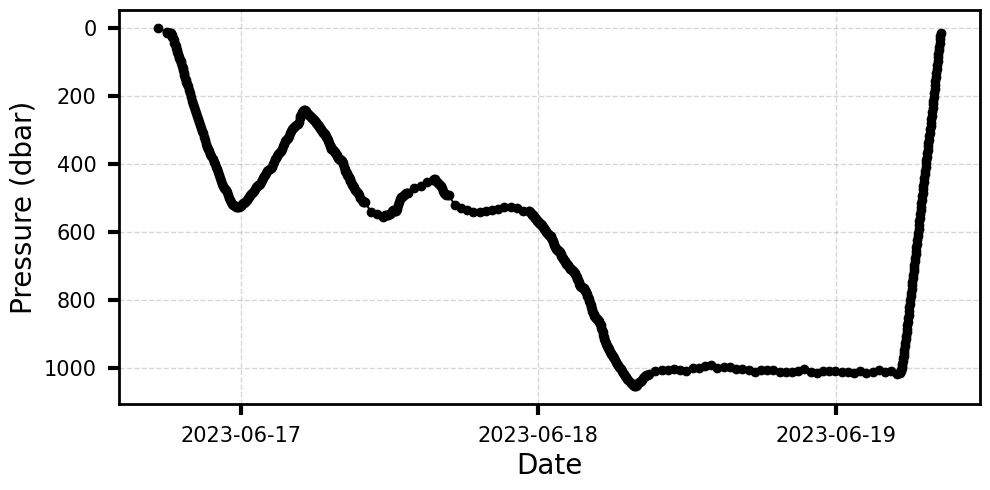

In [4]:
df_cycle = C2
cruise = df_cycle['cruise'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_cycle['Date_time'], df_cycle['Pressure'], linestyle='-', marker='o', color='black')

# Labels
size = 20
pad = 8
ax.set_xlabel('Date', fontsize=size)
ax.set_ylabel('Pressure (dbar)', fontsize=size)

# Tick parameters
l = 8
w = 3
ax.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)
ax.tick_params(axis='x', labelsize=size-5, pad=pad, length=l, width=w)

# Grid and axis styling
ax.grid(True, linestyle='--', linewidth=1, alpha=0.5)
ax.invert_yaxis()

# X-axis ticks: every 24 hours
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # One tick per day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format

plt.xticks(rotation=0, ha='center')

# Set spine width
for spine in ax.spines.values():
    spine.set_linewidth(2)
    
plt.tight_layout()

# Save the figure (optional)
plt.savefig(f'/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S1/Figure_S1.png', dpi=300)

plt.show()